# Notebook 09 — Portfolio Analytics & Risk Management

## Fixed Income From Scratch

**Objective:** Aggregate individual security analytics into a portfolio-level risk view — the daily report a portfolio manager reviews every morning.

### What We'll Build:
1. **Portfolio Construction** — Multi-security MBS portfolio with OAS for each position
2. **Portfolio Summary** — Aggregated risk metrics (weighted OAS, duration, convexity)
3. **Sector Analysis** — Risk by sector/coupon bucket  
4. **Portfolio Scenario Analysis** — Portfolio-level P&L under stress
5. **Portfolio Hedge** — Aggregate key-rate hedge across all positions
6. **Daily P&L Calculation** — Compute portfolio return attribution

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys, os, time

sys.path.insert(0, os.path.abspath('..'))
from utils.curves import bootstrap_treasury_curve, sample_treasury_data
from utils.cashflows import MBSPool, project_mbs_cashflows
from utils.prepayment_model import PrepaymentTuning, project_prepayment_rates
from utils.monte_carlo import RateModelParams, SimulationConfig, simulate_rate_paths
from utils.oas import solve_oas, compute_zoas, compute_path_prices
from utils.scenario import (
    Scenario, run_scenario, compute_hedge_ratios, 
    SecurityAnalytics, PortfolioAnalytics, create_sample_portfolio,
    attribute_pnl
)

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

tenors, par_yields = sample_treasury_data()
tsy_curve = bootstrap_treasury_curve(tenors, par_yields)
params = RateModelParams()
tuning = PrepaymentTuning()

print("Portfolio analytics modules loaded.")

Portfolio analytics modules loaded.


---
## 1. Portfolio Construction & OAS Analysis

We build a $20 million MBS portfolio spanning the coupon stack from 4.5% to 7.0%, then compute OAS, duration, and risk measures for each position.

In [4]:
# Build portfolio: compute OAS for each security
portfolio_specs = create_sample_portfolio()
config = SimulationConfig(num_paths=128, num_months=348, seed=42)

print("Computing OAS for each security in the portfolio...")
t0 = time.time()

securities = []
for spec in portfolio_specs:
    pool = MBSPool(
        original_balance=spec['face'], current_balance=spec['face'] * 0.988,
        wac=spec['wac'], net_coupon=spec['net_cpn'],
        wam=360 - spec['age'], age=spec['age'], original_term=360
    )
    
    paths = simulate_rate_paths(tsy_curve, params, config)
    oas = solve_oas(pool, paths, spec['price'], tuning)
    zoas = compute_zoas(pool, tsy_curve, spec['price'], tuning)
    
    # Quick WAL/CPR from sample paths
    wals, cprs = [], []
    for i in range(min(30, paths.num_paths)):
        mtg = paths.mortgage_rates[i, :pool.wam]
        pr = project_prepayment_rates(pool.wac, mtg, pool.wam, pool.age, pool.original_term, tuning=tuning)
        cf = project_mbs_cashflows(pool, smm_vector=pr.total_smm)
        wals.append(cf.weighted_avg_life)
        cprs.append(np.mean(pr.total_cpr))
    
    oas_bps = oas * 10000 if not np.isnan(oas) else 0
    zoas_bps = zoas * 10000 if not np.isnan(zoas) else 0
    
    # Approximate OA duration from WAL (simplified for portfolio speed)
    approx_dur = np.mean(wals) * 0.65  # MBS duration ≈ 65% of WAL
    approx_cvx = -approx_dur * 40      # Rough negative convexity
    
    # Approximate partial durations from duration
    dur = approx_dur
    krd = {'2Y': dur * 0.07, '5Y': dur * 0.29, '10Y': dur * 0.58, '30Y': dur * 0.06}
    
    sec = SecurityAnalytics(
        name=spec['name'], cusip=f'FN{spec["wac"]*1000:.0f}',
        coupon=spec['net_cpn'], price=spec['price'],
        face_value=spec['face'],
        market_value=spec['face'] * spec['price'] / 100,
        oas_bps=oas_bps, zoas_bps=zoas_bps,
        option_cost_bps=zoas_bps - oas_bps,
        oa_duration=approx_dur, oa_convexity=approx_cvx,
        wal=np.mean(wals), avg_cpr=np.mean(cprs),
        partial_durations=krd, sector=spec['sector']
    )
    securities.append(sec)
    print(f"  {spec['name']:<12s}  OAS={oas_bps:6.1f}bp  WAL={np.mean(wals):5.1f}Y  Dur={approx_dur:.2f}  CPR={np.mean(cprs)*100:.1f}%")

elapsed = time.time() - t0
print(f"\nPortfolio OAS computed in {elapsed:.0f}s")

# Create portfolio object
portfolio = PortfolioAnalytics(securities=securities)

Computing OAS for each security in the portfolio...
  FNMA 4.5%     OAS=  56.8bp  WAL=  9.6Y  Dur=6.24  CPR=5.7%
  FNMA 5.0%     OAS=  69.1bp  WAL=  8.6Y  Dur=5.61  CPR=7.1%
  FNMA 5.5%     OAS=  95.4bp  WAL=  7.5Y  Dur=4.89  CPR=8.5%
  FNMA 6.0%     OAS= 107.0bp  WAL=  6.6Y  Dur=4.26  CPR=9.9%
  FNMA 6.5%     OAS= 109.0bp  WAL=  5.6Y  Dur=3.66  CPR=11.4%
  GNMA 5.5%     OAS=  85.0bp  WAL=  7.8Y  Dur=5.04  CPR=8.4%
  FNMA 7.0%     OAS=  85.6bp  WAL=  4.1Y  Dur=2.64  CPR=13.2%

Portfolio OAS computed in 27s


---
## 2. Portfolio Summary — The Morning Risk Report

This is the table a PM sees every morning — every position with its key risk metrics, plus the portfolio aggregate.

In [7]:
# Display portfolio summary
summary = portfolio.summary_table()
print("PORTFOLIO SUMMARY — MBS PASS-THROUGH BOOK")
print("=" * 110)
print(summary.round(2).to_string())

print(f"\n{'='*60}")
print(f"PORTFOLIO AGGREGATE RISK METRICS")
print(f"{'='*60}")
print(f"  Total Face:           ${portfolio.total_face/1e6:>8.1f}M")
print(f"  Total Market Value:   ${portfolio.total_market_value/1e6:>8.1f}M")
print(f"  Weighted OAS:         {portfolio.weighted_oas:>8.1f} bps")
print(f"  Weighted OA Duration: {portfolio.weighted_duration:>8.2f}")
print(f"  Weighted OA Convexity:{portfolio.weighted_convexity:>8.1f}")
print(f"  Weighted WAL:         {portfolio.weighted_wal:>8.2f} years")
print(f"  Portfolio DV01:       ${portfolio.portfolio_dv01:>8,.0f}")

PORTFOLIO SUMMARY — MBS PASS-THROUGH BOOK
           Coupon (%)   Price  Face ($K)  MV ($K)  OAS (bps)  Opt Cost  OA Dur  OA Cvx   WAL  CPR (%)
Security                                                                                             
FNMA 4.5%        4.50   95.00     2000.0   1900.0      56.79     25.87    6.24 -249.50  9.60     5.72
FNMA 5.0%        5.00   97.50     3000.0   2925.0      69.11     36.23    5.61 -224.52  8.64     7.07
FNMA 5.5%        5.50   99.00     5000.0   4950.0      95.43     42.37    4.89 -195.71  7.53     8.48
FNMA 6.0%        6.00  101.00     4000.0   4040.0     107.05     46.51    4.26 -170.59  6.56     9.91
FNMA 6.5%        6.50  103.00     3000.0   3090.0     109.02     34.38    3.66 -146.39  5.63    11.39
GNMA 5.5%        5.50   99.50     2000.0   1990.0      84.99     44.63    5.04 -201.71  7.76     8.43
FNMA 7.0%        7.00  105.00     1000.0   1050.0      85.58      6.89    2.64 -105.75  4.07    13.17
PORTFOLIO        5.67   99.72    20000.0

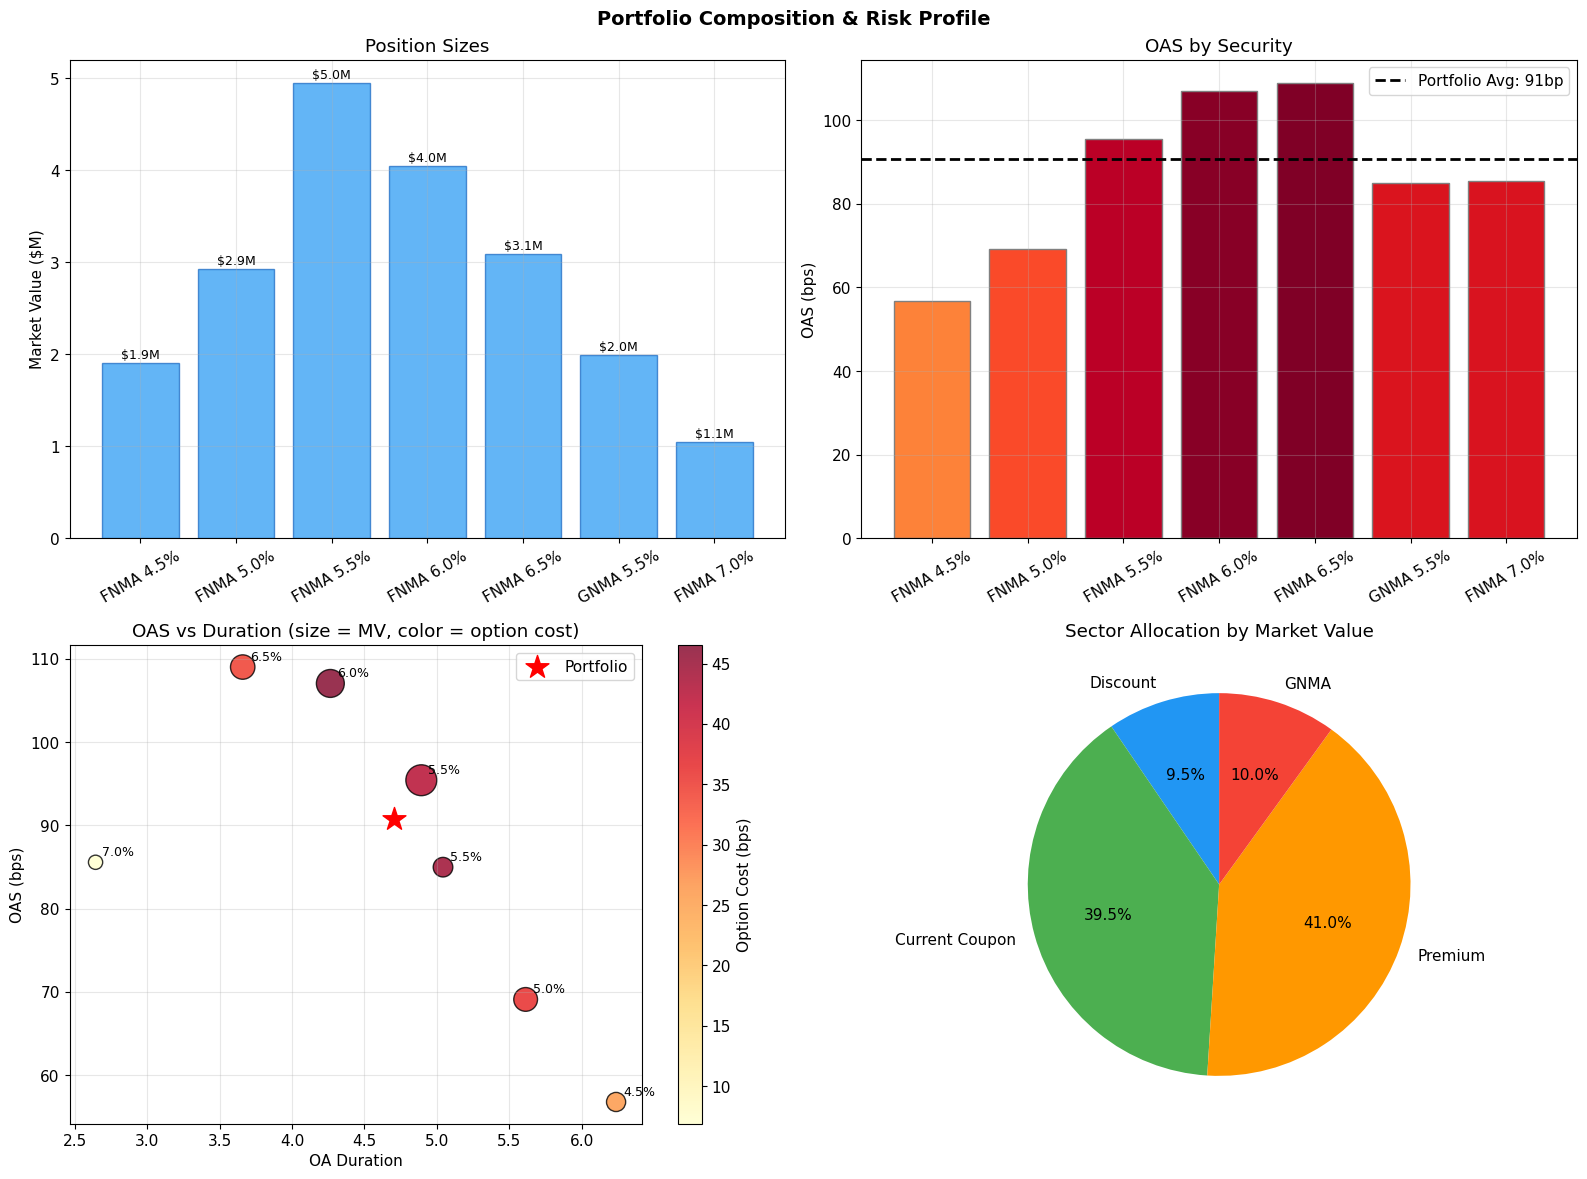

In [8]:
# Visualize portfolio composition
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

names = [s.name for s in securities]
faces = [s.face_value/1e6 for s in securities]
mvs = [s.market_value/1e6 for s in securities]
oases = [s.oas_bps for s in securities]
durs = [s.oa_duration for s in securities]
wals = [s.wal for s in securities]
opt_costs = [s.option_cost_bps for s in securities]

# Position sizes
ax = axes[0, 0]
bars = ax.bar(names, mvs, color='#2196F3', alpha=0.7, edgecolor='#1565C0')
ax.set_ylabel('Market Value ($M)')
ax.set_title('Position Sizes')
ax.tick_params(axis='x', rotation=30)
for bar, mv in zip(bars, mvs):
    ax.text(bar.get_x() + bar.get_width()/2, mv + 0.05, f'${mv:.1f}M', ha='center', fontsize=9)

# OAS by security
ax = axes[0, 1]
colors_oas = plt.cm.YlOrRd(np.array(oases) / max(oases))
bars = ax.bar(names, oases, color=colors_oas, edgecolor='gray')
ax.axhline(y=portfolio.weighted_oas, color='black', linewidth=2, linestyle='--', 
           label=f'Portfolio Avg: {portfolio.weighted_oas:.0f}bp')
ax.set_ylabel('OAS (bps)')
ax.set_title('OAS by Security')
ax.legend()
ax.tick_params(axis='x', rotation=30)

# OAS vs Duration scatter
ax = axes[1, 0]
scatter = ax.scatter(durs, oases, s=[mv*100 for mv in mvs], c=opt_costs, 
                      cmap='YlOrRd', edgecolors='black', linewidth=1, alpha=0.8)
for s in securities:
    ax.annotate(s.name.split()[-1], xy=(s.oa_duration, s.oas_bps), 
                xytext=(5, 5), textcoords='offset points', fontsize=9)
ax.set_xlabel('OA Duration')
ax.set_ylabel('OAS (bps)')
ax.set_title('OAS vs Duration (size = MV, color = option cost)')
plt.colorbar(scatter, ax=ax, label='Option Cost (bps)')
# Plot portfolio point
ax.scatter([portfolio.weighted_duration], [portfolio.weighted_oas], 
           s=300, marker='*', c='red', zorder=5, label='Portfolio')
ax.legend()

# Sector breakdown
ax = axes[1, 1]
sector_df = portfolio.sector_summary()
sector_labels = sector_df.index.tolist()
sector_mvs = sector_df['MV ($K)'].values / 1000
sector_colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336'][:len(sector_labels)]
wedges, texts, autotexts = ax.pie(sector_mvs, labels=sector_labels, autopct='%1.1f%%',
                                    colors=sector_colors, startangle=90)
ax.set_title('Sector Allocation by Market Value')

plt.suptitle('Portfolio Composition & Risk Profile', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. Sector Analysis & Key-Rate Exposure

SECTOR SUMMARY
                Count  MV ($K)  Weight (%)  Wtd OAS  Wtd Dur  Wtd WAL
Sector                                                               
Discount            1   1900.0        9.53    56.79     6.24     9.60
Current Coupon      2   7875.0       39.48    85.65     5.16     7.94
Premium             3   8180.0       41.01   105.04     3.83     5.89
GNMA                1   1990.0        9.98    84.99     5.04     7.76

PORTFOLIO KEY-RATE DURATION PROFILE
----------------------------------------
  10Y     Duration: 2.729  DV01: $   5,443
  2Y      Duration: 0.329  DV01: $     657
  30Y     Duration: 0.282  DV01: $     563
  5Y      Duration: 1.364  DV01: $   2,721
  Total   Duration: 4.705  DV01: $   9,384


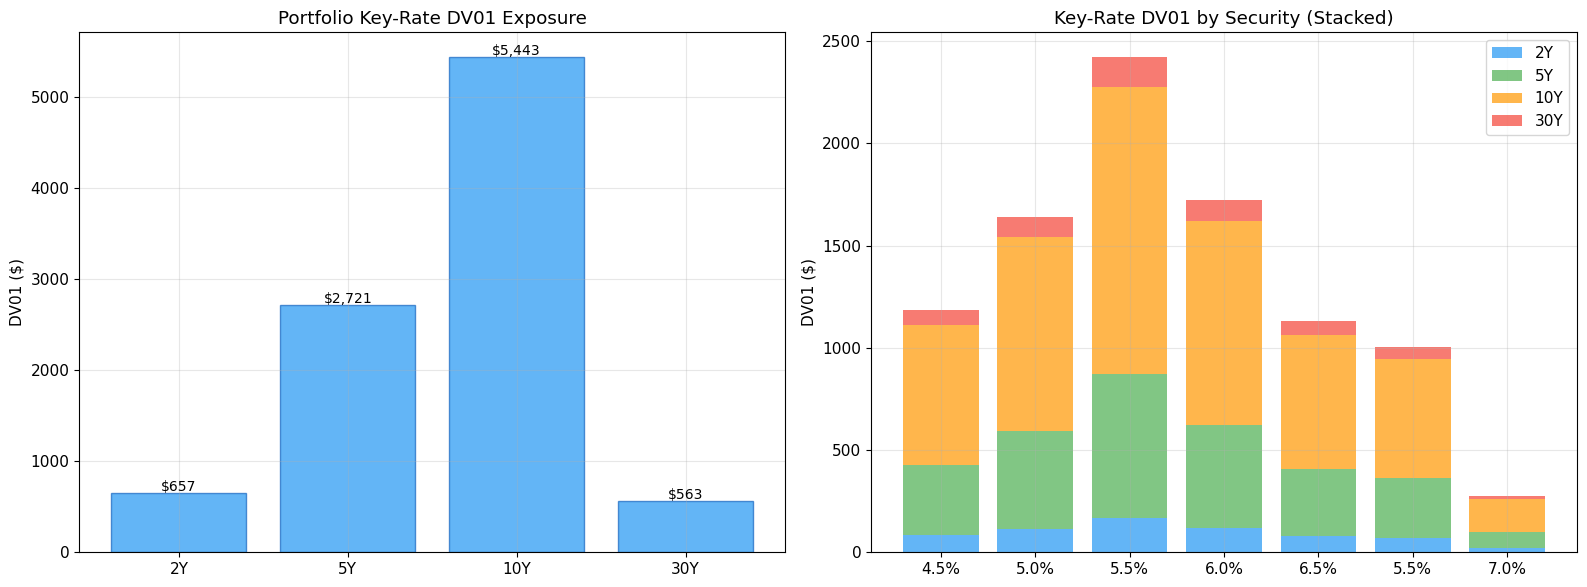

In [10]:
# Sector summary table
print("SECTOR SUMMARY")
print("=" * 75)
sector_df = portfolio.sector_summary()
print(sector_df.round(2).to_string())

# Portfolio key-rate exposure
agg_krd = portfolio.aggregate_partial_durations
print(f"\nPORTFOLIO KEY-RATE DURATION PROFILE")
print("-" * 40)
total_krd = 0
for tenor, dur in sorted(agg_krd.items()):
    dv01 = dur * portfolio.total_market_value / 10000
    print(f"  {tenor:<6s}  Duration: {dur:.3f}  DV01: ${dv01:>8,.0f}")
    total_krd += dur
print(f"  {'Total':<6s}  Duration: {total_krd:.3f}  DV01: ${total_krd * portfolio.total_market_value / 10000:>8,.0f}")

# KRD bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Portfolio KRD
tenors_kr = list(agg_krd.keys())
durs_kr = list(agg_krd.values())
dv01s_kr = [d * portfolio.total_market_value / 10000 for d in durs_kr]
ax1.bar(tenors_kr, dv01s_kr, color='#2196F3', alpha=0.7, edgecolor='#1565C0')
ax1.set_ylabel('DV01 ($)')
ax1.set_title('Portfolio Key-Rate DV01 Exposure')
for i, (t, v) in enumerate(zip(tenors_kr, dv01s_kr)):
    ax1.text(i, v + 20, f'${v:,.0f}', ha='center', fontsize=10)

# KRD by security (stacked)
ax2_data = {}
for s in securities:
    for t in ['2Y', '5Y', '10Y', '30Y']:
        if t not in ax2_data:
            ax2_data[t] = []
        ax2_data[t].append(s.partial_durations.get(t, 0) * s.market_value / 10000)

x = np.arange(len(names))
bottom = np.zeros(len(names))
colors_stack = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']
for idx, (tenor, vals) in enumerate(ax2_data.items()):
    ax2.bar(x, vals, bottom=bottom, label=tenor, color=colors_stack[idx], alpha=0.7)
    bottom += np.array(vals)
ax2.set_xticks(x)
ax2.set_xticklabels([n.split()[-1] for n in names], rotation=0)
ax2.set_ylabel('DV01 ($)')
ax2.set_title('Key-Rate DV01 by Security (Stacked)')
ax2.legend()

plt.tight_layout()
plt.show()

---
## 4. Portfolio-Level Treasury Hedge

In [12]:
# Compute aggregate hedge
hedge = compute_hedge_ratios(agg_krd, portfolio.total_market_value)

print("PORTFOLIO HEDGE CONSTRUCTION")
print("=" * 65)
print(f"Portfolio Market Value: ${portfolio.total_market_value/1e6:.1f}M")
print(f"Portfolio DV01: ${portfolio.portfolio_dv01:,.0f}")
print()
hedge_durations = {'2Y': 1.95, '5Y': 4.70, '10Y': 8.80, '30Y': 21.50}
print(f"{'Tenor':<8} {'Port KRD':>8} {'Port DV01':>10} {'Hedge Notional':>15} {'Direction':>10}")
print("-" * 65)
total_hedge = 0
for tenor in ['2Y', '5Y', '10Y', '30Y']:
    krd = agg_krd.get(tenor, 0)
    dv01 = krd * portfolio.total_market_value / 10000
    notional = hedge.hedge_positions.get(tenor, 0)
    total_hedge += abs(notional)
    direction = 'SHORT' if notional < 0 else 'LONG'
    print(f"{tenor:<8} {krd:>8.3f} {dv01:>10,.0f} ${abs(notional):>13,.0f} {direction:>10}")

print(f"\nTotal hedge notional: ${total_hedge/1e6:.1f}M")
print(f"Hedge-to-MBS ratio: {total_hedge/portfolio.total_market_value:.2f}x")
print(f"Residual duration: {hedge.hedged_duration:.4f}")

PORTFOLIO HEDGE CONSTRUCTION
Portfolio Market Value: $19.9M
Portfolio DV01: $9,384

Tenor    Port KRD  Port DV01  Hedge Notional  Direction
-----------------------------------------------------------------
2Y          0.329        657 $    3,368,543      SHORT
5Y          1.364      2,721 $    5,790,003      SHORT
10Y         2.729      5,443 $    6,184,776      SHORT
30Y         0.282        563 $      261,873      SHORT

Total hedge notional: $15.6M
Hedge-to-MBS ratio: 0.78x
Residual duration: 0.0000


---
## 5. Portfolio-Level Scenario P&L

Apply rate shocks to the entire portfolio and show the aggregate impact.

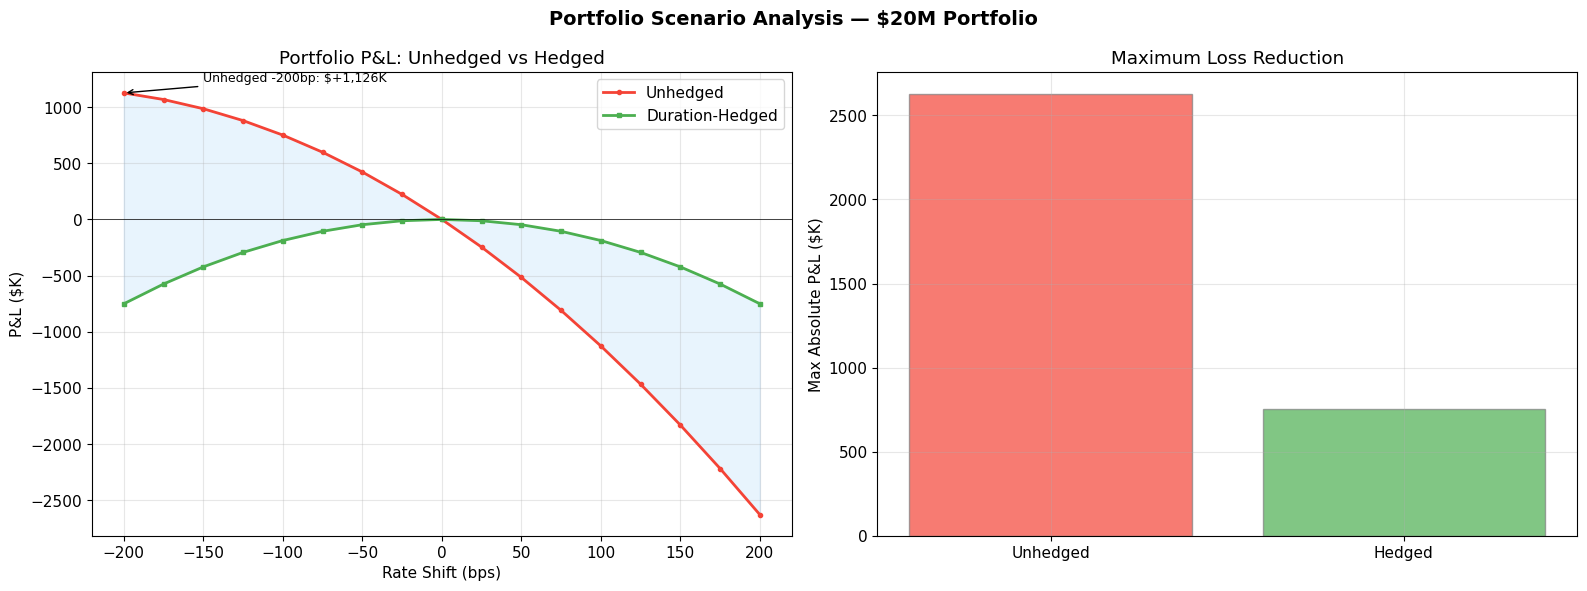

Maximum unhedged loss (±200bp): $2,627K
Maximum hedged loss (±200bp):   $751K
Risk reduction: 71%


In [14]:
# Compute portfolio scenario P&L using duration approximation
shifts = np.arange(-200, 201, 25)
port_pnl = []
hedged_pnl = []

for s in shifts:
    total_mbs_pnl = 0
    total_tsy_pnl = 0
    
    for sec in securities:
        # MBS P&L: -Duration × Δr × MV + 0.5 × Convexity × Δr² × MV
        dr = s / 10000
        mbs = (-sec.oa_duration * dr + 0.5 * sec.oa_convexity * dr**2) * sec.market_value
        total_mbs_pnl += mbs
        
    # Treasury hedge P&L
    for tenor in ['2Y', '5Y', '10Y', '30Y']:
        notional = hedge.hedge_positions.get(tenor, 0)
        dur = hedge_durations[tenor]
        total_tsy_pnl += -dur * (s/10000) * notional
    
    port_pnl.append(total_mbs_pnl / 1000)  # In $K
    hedged_pnl.append((total_mbs_pnl + total_tsy_pnl) / 1000)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(shifts, port_pnl, 'o-', linewidth=2, markersize=3, label='Unhedged', color='#F44336')
ax1.plot(shifts, hedged_pnl, 's-', linewidth=2, markersize=3, label='Duration-Hedged', color='#4CAF50')
ax1.axhline(y=0, color='black', linewidth=0.5)
ax1.fill_between(shifts, port_pnl, hedged_pnl, alpha=0.1, color='#2196F3')
ax1.set_xlabel('Rate Shift (bps)')
ax1.set_ylabel('P&L ($K)')
ax1.set_title('Portfolio P&L: Unhedged vs Hedged')
ax1.legend()
ax1.annotate(f'Unhedged -200bp: ${port_pnl[0]:+,.0f}K', xy=(-200, port_pnl[0]),
            xytext=(-150, port_pnl[0] + 100), fontsize=9, arrowprops=dict(arrowstyle='->'))

# Risk reduction
ax2.bar(['Unhedged', 'Hedged'], 
        [max(abs(min(port_pnl)), abs(max(port_pnl))),
         max(abs(min(hedged_pnl)), abs(max(hedged_pnl)))],
        color=['#F44336', '#4CAF50'], alpha=0.7, edgecolor='gray')
ax2.set_ylabel('Max Absolute P&L ($K)')
ax2.set_title('Maximum Loss Reduction')

plt.suptitle(f'Portfolio Scenario Analysis — ${portfolio.total_market_value/1e6:.0f}M Portfolio', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

max_unhedged = max(abs(min(port_pnl)), abs(max(port_pnl)))
max_hedged = max(abs(min(hedged_pnl)), abs(max(hedged_pnl)))
print(f"Maximum unhedged loss (±200bp): ${max_unhedged:,.0f}K")
print(f"Maximum hedged loss (±200bp):   ${max_hedged:,.0f}K")
print(f"Risk reduction: {(1 - max_hedged/max_unhedged)*100:.0f}%")

---
## Summary — The Complete Fixed Income From Scratch Platform

### Project Recap — 9 Notebooks, 10 Modules:

| Phase | Notebooks | Concepts |
|:------|:----------|:---------|
| **Phase 1** | 01-02 | Curve construction, MBS cash flows, Z-spread, nominal spread |
| **Phase 2** | 03-04 | Multi-factor prepay model, CMO structuring (sequential, PAC, IO/PO) |
| **Phase 3** | 05-07 | Volatility surfaces, SABR, Monte Carlo, **OAS with full risk decomposition** |
| **Phase 4** | 08-09 | Scenario analysis, hedging, attribution, **portfolio analytics** |

### Analytics Pipeline (end-to-end):
```
Market Data → Curve Construction → Forward Rates → MC Path Generation
                                                          ↓
Volatility Surface → Factor Calibration ──────────────→ Rate Paths
                                                          ↓
                                    Prepayment Model → Path CPRs
                                                          ↓
                    Pool Characteristics → Cash Flow Engine → Path Cash Flows
                                                          ↓
                                            Discounting → Path PVs → OAS
                                                          ↓
                              Duration / Convexity / KRD / Prepay Dur / Vol Dur
                                                          ↓
                         Scenario Analysis → Hedging → Attribution → Portfolio Risk
```

### What This Demonstrates:
- **Quantitative depth**: every calculation built from first principles
- **Financial intuition**: each notebook explains WHY, not just HOW
- **Production awareness**: portfolio-level analytics, hedging, attribution
- **Software engineering**: modular design with 10 reusable Python modules
- **End-to-end pipeline**: from raw yield data to portfolio risk management